# Haplosaurus

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/grid/koo/home/schilder/projects/GenomeEncoder/')
import pandas as pd
import src.haplosaurus as hs
import src.variant_annotation as va
import src.ESM as ESM
import src.onekg as onekg
import src.utils as utils
import src.gprofiler as gp
# import src.proteingym as pg
from src.config import DATA_DIR
from src.haplosaurus  import DIR_DICT

import sys
sys.path.append('ProteinGym')
import proteingym.utils.download as pgd # Local version


In [1]:
# %%R

# db = EnsDb.Hsapiens.v86::EnsDb.Hsapiens.v86
# # get the transcript to protein ID mappings
# txs <- GenomicFeatures::transcripts(db, columns = c("tx_id","protein_id"))
# txs <- txs[!is.na(txs$protein_id)]
# data.table::fwrite(data.frame(txs), "data/bioc/bioc_tx_to_prot.csv.gz")

## Get transcripts

In [3]:
# hs_db = hs.get_figshare("haplotype_analysis_database.zip")
# #  List all files in the directory
# hs_db_files = [f"{hs_db}/{x}" for x in os.listdir(hs_db)]
# hs_db_sql = [x for x in hs_db_files if x.endswith(".sql.gz")][0]
# hs_db_files
# import mysql.connector
# conn = mysql.connector.connect(
# host="localhost",
# user="root",
# password="root",
# database="haplotype_analysis_database"
# )
# cursor = conn.cursor() 

In [ ]:
# Haplosaurus protein IDs
tx_df = pd.read_excel(DATA_DIR + "haplosaurus/41467_2018_6542_MOESM4_ESM.xlsx")
print(tx_df.shape)
# Bioconductor transcript to protein ID
tx_to_prot = pd.read_csv(DATA_DIR + "bioc/bioc_tx_to_prot.csv.gz")
print(tx_to_prot.shape)
tx_df = tx_df.merge(tx_to_prot.drop_duplicates(subset=['tx_id', 'protein_id']),
                    left_on="Ensembl Protein ID", 
                    right_on="protein_id", 
                    how="inner") 
print(tx_df.shape)
tx_df.head()

(20166, 6)
(109705, 9)
(18494, 15)


/grid/it/data/elzar/easybuild/software/Python/3.9.5-GCCcore-10.3.0/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3098: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,Ensembl Gene ID,Ensembl Protein ID,Gene Name,Number of Haplotypes,Number of Haplotypes FoO>=1%,Frequency Rank of Reference Protein Haplotype,seqnames,start,end,width,strand,protein_id,uniprot_id,tx_biotype,tx_id
0,ENSG00000121410,ENSP00000263100,A1BG,44,3.0,2.0,19,58346850,58353499,6650,-,ENSP00000263100,P04217,protein_coding,ENST00000263100
1,ENSG00000148584,ENSP00000363107,A1CF,25,2.0,1.0,10,50806562,50885675,79114,-,ENSP00000363107,Q9NQ94,protein_coding,ENST00000373995
2,ENSG00000175899,ENSP00000323929,A2M,69,5.0,10.0,12,9067712,9116157,48446,-,ENSP00000323929,P01023,protein_coding,ENST00000318602
3,ENSG00000166535,ENSP00000299698,A2ML1,171,9.0,10.0,12,8822472,8876785,54314,+,ENSP00000299698,A8K2U0,protein_coding,ENST00000299698
4,ENSG00000184389,ENSP00000475261,A3GALT2,34,1.0,1.0,1,33306766,33321098,14333,-,ENSP00000475261,U3KPV4,protein_coding,ENST00000442999


<AxesSubplot:>

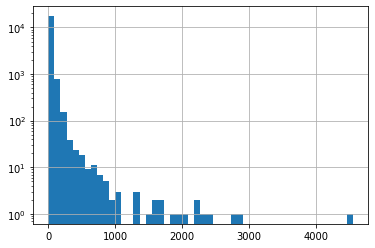

In [8]:
tx_df['Number of Haplotypes'].hist(bins=50, log=True)

In [9]:
# Remove MUC genes with lots of haplotypes as these may be artifacts
# tx_df = tx_df[(tx_df['Number of Haplotypes'] > 50) & (tx_df['Number of Haplotypes'] < 1000)]
# tx_df['Gene Name'].str.startswith('MUC')
tx_df.sort_values('Number of Haplotypes', ascending=False)
tx_ids = list(set(tx_df['tx_id'].tolist()))
tx_ids.reverse() # Start with the smallest number of haplotypes
# tx_ids = tx_ids[:5]

print(len(tx_ids),"transcripts")

18494 transcripts


## Get variant sets
Collect sets of variants (pathogenic, benign, 1KG) for each transcripts. 
Only trancripts with at least one pathogenic variant and one benign variant of the specifiied consequence type are included. Pathogenic/benign variants present in the 1KG cohort are excluded.

### Missense

In [10]:
variant_sets_dict = {
    ('SO:0001583','missense_variant'):{},
    ('SO:0001589','frameshift_variant'):{},
    ('SO:0001906','feature_truncation'):{}
    }

In [ ]:
for so_term, consequence_type in variant_sets_dict.keys():
    print(so_term, consequence_type)
    # Gather variant sets
    variant_sets_dict[(so_term, consequence_type)] = hs.get_variant_sets(
        tx_ids = tx_ids,
        so_term = so_term,
        consequence_type = consequence_type,
        # cache_only = cache_only, # Use cached files only (faster)
        error=False,
        # force=True
        )


In [21]:
# Get the number of transcripts with variant sets per consequence type
{k:len(v) for k,v in variant_sets_dict.items()}

{('SO:0001583', 'missense_variant'): 1070,
 ('SO:0001589', 'frameshift_variant'): 0,
 ('SO:0001906', 'feature_truncation'): 0}

## Get haplotypes


In [46]:
haplotypes = hs.get_haplotypes(
#     tx_ids=tx_ids, #variant_sets.keys(),
    cache_only=True, # Use cached files only (faster)
    use_protein_ids=True,
    force=False
    )


Found 403 haplotypes in /grid/koo/home/schilder/projects/data/haplosaurus/haplotypes/


Getting haplotypes:   0%|          | 0/403 [00:00<?, ?it/s]

  0%|          | 0/403 [00:00<?, ?it/s]

In [50]:
haplotypes['ENSP00000454071']['protein_haplotypes'].__len__()

56

## Get reference haplotypes

In [15]:
haplotypes_ref = hs.get_haplotype_ref(haplotypes)
haplotypes_ref_seqs, missing_seqs = hs.get_haplotype_seqs(
    haplotypes_ref,
    return_missing=True,
    verbose=True)
(len(haplotypes), 
 len(haplotypes_ref), 
 len(haplotypes_ref_seqs),
 len(missing_seqs))


Processing transcripts:   0%|          | 0/402 [00:00<?, ?it/s]

  0%|          | 0/402 [00:00<?, ?it/s]

No seqs found for ENST00000359568
No seqs found for ENST00000324093
No seqs found for ENST00000405460
No seqs found for ENST00000354785


(402, 402, 398, 4)

## Add variants to haplotypes

In [ ]:
haplotypes_wt, haplotypes_pathogenic, haplotypes_benign = hs.add_variant_to_haplotypes(
  haplotypes=haplotypes, 
  variant_sets=variant_sets, 
  tx_ids=tx_ids,
  consequence_terms=['missense_variant'],
  max_transcripts=5,
  ref_checks=False,
  verbose=True
  )
# check length of each group
len(haplotypes_wt), len(haplotypes_pathogenic), len(haplotypes_benign)

In [17]:
print(hs.get_haplotype_counts(haplotypes_wt))
print(hs.get_haplotype_counts(haplotypes_pathogenic))
print(hs.get_haplotype_counts(haplotypes_benign))


{'ENST00000544455': 228, 'ENST00000220676': 122, 'ENST00000392403': 92, 'ENST00000300589': 105, 'ENST00000373818': 57}
{'ENST00000544455': 228, 'ENST00000220676': 122, 'ENST00000392403': 92, 'ENST00000300589': 105, 'ENST00000373818': 57}
{'ENST00000544455': 228, 'ENST00000220676': 122, 'ENST00000392403': 92, 'ENST00000300589': 105, 'ENST00000373818': 57}


In [36]:
esm_vep = ESM.merge_vep("~/projects/data/1KG/vep")

Found 153 wt-marginals files


Reading files: 100%|██████████| 153/153 [00:00<00:00, 226.41it/s]


Found 153 masked-marginals files


Reading files: 100%|██████████| 153/153 [00:00<00:00, 204.41it/s]


Found 151 pseudo-ppl files


Reading files: 100%|██████████| 151/151 [00:00<00:00, 214.74it/s]


In [ ]:
esm_vep

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,esm1v_t33_650M_UR90S_1,scoring_strategy,is_ref,model_location,variant_set
0,ENSP00000454071:REF,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,W10R,MGPWGWKLRRTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-5.125133,wt-marginals,True,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions
1,ENSP00000454071:REF,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15P,MGPWGWKLRWTVALPLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-8.496380,wt-marginals,True,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions
2,ENSP00000454071:REF,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15R,MGPWGWKLRWTVALRLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-9.366632,wt-marginals,True,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions
3,ENSP00000454071:REF,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,A18V,MGPWGWKLRWTVALLLAVAGTAVGDRCERNEFQCQDGKCISYKWVC...,Benign,-4.035277,wt-marginals,True,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions
4,ENSP00000454071:REF,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,G20R,MGPWGWKLRWTVALLLAAARTAVGDRCERNEFQCQDGKCISYKWVC...,Benign,-4.446632,wt-marginals,True,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions
...,...,...,...,...,...,...,...,...,...,...,...
3988,ENSP00000305714:310I>V,NP_006120.1,MPGVARLPLLLGLLLLPRPGRPLDLADYTYDLAEEDDSEPLNYKDP...,C322Y,MPGVARLPLLLGLLLLPRPGRPLDLADYTYDLAEEDDSEPLNYKDP...,Pathogenic,-9242.119239,pseudo-ppl,False,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions
3989,ENSP00000305714:310I>V,NP_006120.1,MPGVARLPLLLGLLLLPRPGRPLDLADYTYDLAEEDDSEPLNYKDP...,R371H,MPGVARLPLLLGLLLLPRPGRPLDLADYTYDLAEEDDSEPLNYKDP...,Benign,-9242.119239,pseudo-ppl,False,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions
3990,ENSP00000305714:310I>V,NP_006120.1,MPGVARLPLLLGLLLLPRPGRPLDLADYTYDLAEEDDSEPLNYKDP...,G713S,MPGVARLPLLLGLLLLPRPGRPLDLADYTYDLAEEDDSEPLNYKDP...,Benign,-9242.119239,pseudo-ppl,False,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions
3991,ENSP00000305714:310I>V,NP_006120.1,MPGVARLPLLLGLLLLPRPGRPLDLADYTYDLAEEDDSEPLNYKDP...,V719I,MPGVARLPLLLGLLLLPRPGRPLDLADYTYDLAEEDDSEPLNYKDP...,Benign,-9242.119239,pseudo-ppl,False,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions


Text(0.5, 1.1, 'Protein: NP_000518.1, Haplotypes: 1, Variants: 639')

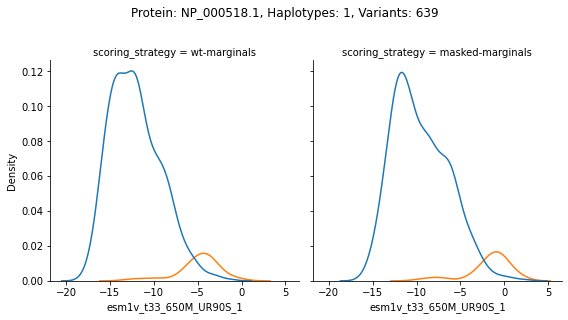

In [41]:
np_id='NP_000518.1'

import seaborn as sns
# Get filtered data
filtered_data = esm_vep[esm_vep['protein'] == np_id]

# Create facet grid
g = sns.FacetGrid(data=filtered_data, 
                  col='scoring_strategy',
                  height=4,
                  aspect=1)

# Plot KDE
g.map_dataframe(sns.kdeplot, 
                x='esm1v_t33_650M_UR90S_1',
                hue='DMS_bin_score')

# Add title with protein, haplotype and mutant counts
n_haplotypes = filtered_data['haplotype'].nunique()
n_mutants = filtered_data['mutant'].nunique()
g.fig.suptitle(f'Protein: {np_id}, Haplotypes: {n_haplotypes}, Variants: {n_mutants}', y=1.1)

# Add vertical lines for REF haplotypes
# for ax in g.axes.flat:
#     ref_data = esm_vep[(esm_vep['protein'] == np_id) & 
#                        (esm_vep['is_ref'] == True)]
#     for _, row in ref_data.iterrows():
#         ax.axvline(x=row['esm1v_t33_650M_UR90S_1'], 
#                   color='black', 
#                   linestyle='--', 
#                   alpha=0.5)


Removed 0 rows with NA values in esm1v_t33_650M_UR90S_1


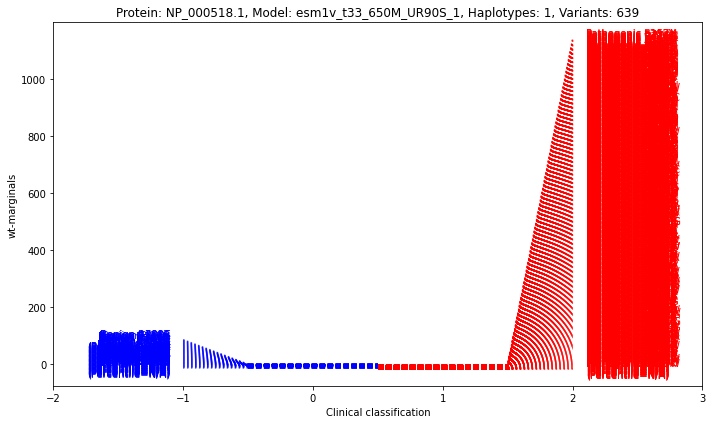

In [ ]:

ESM.plot_vep_violin(esm_vep.loc[(esm_vep['protein'] == np_id) & (esm_vep['scoring_strategy'] == "wt-marginals")], 
                    model_location="esm1v_t33_650M_UR90S_1")

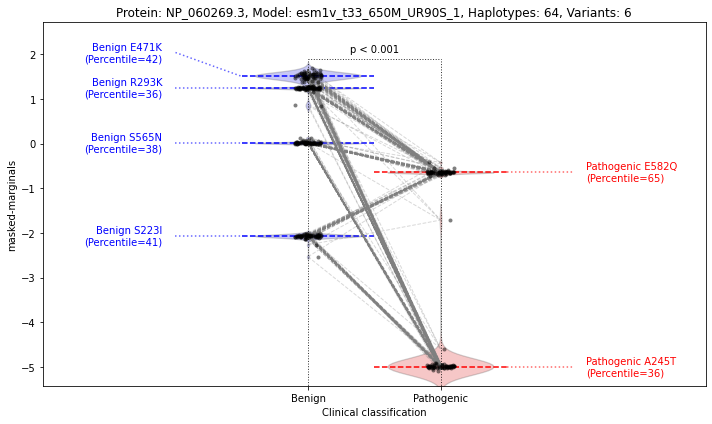

In [40]:
ESM.plot_vep_violin(esm_vep.loc[(esm_vep['protein'] == "NP_060269.3") & (esm_vep['scoring_strategy'] == "masked-marginals")], 
                    model_location="esm1v_t33_650M_UR90S_1")

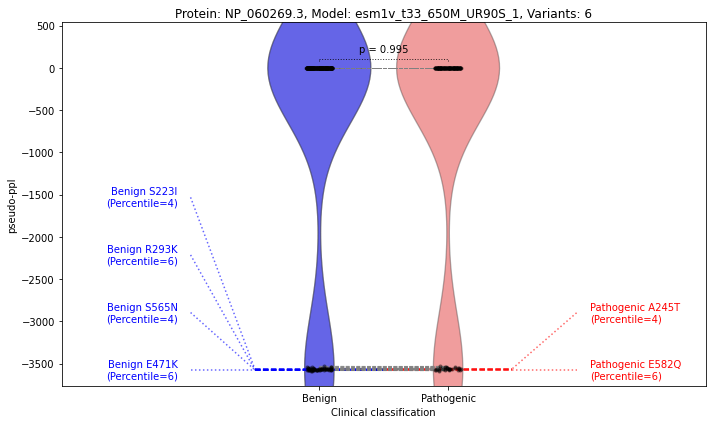

In [39]:
ESM.plot_vep_violin(esm_vep.loc[(esm_vep['protein'] == "NP_060269.3") & (esm_vep['scoring_strategy'] == "pseudo-ppl")], 
                    model_location="esm1v_t33_650M_UR90S_1")

In [73]:
candidate_proteins = utils.get_candidate_proteins()
candidate_proteins = gp.map_ids(candidate_proteins,  
                                on_left='ENSP', 
                                target_namespace='ENST')
candidate_proteins = gp.map_ids(candidate_proteins,  
                                on_left='ENSP', 
                                target_namespace='REFSEQ_PEPTIDE')

candidate_proteins 


Running gprofiler.convert with 11 queries.
Running gprofiler.convert with 11 queries.


,Gene,Protein Common Name,RefSeq Protein,RefSeq Transcript,ENSP,RefSeq Protein Stable,ENST,REFSEQ_PEPTIDE,HGNC
0,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,ENSP00000377192,NP_001346945,ENST00000369620,NP_000393.4,G6PD
1,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,ENSP00000377192,NP_001346945,ENST00000369620,NP_001035810.1,G6PD
2,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,ENSP00000377192,NP_001346945,ENST00000369620,NP_001346945.1,G6PD
3,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,ENSP00000377192,NP_001346945,ENST00000393562,NP_000393.4,G6PD
4,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,ENSP00000377192,NP_001346945,ENST00000393562,NP_001035810.1,G6PD
...,...,...,...,...,...,...,...,...,...
15954,KCNH2,Potassium Voltage-Gated Channel Subfamily H Me...,NP_000229.1,NM_000238.4,ENSP00000262186,NP_000229,ENST00000713701,NP_001393682.1,KCNH2
15955,KCNH2,Potassium Voltage-Gated Channel Subfamily H Me...,NP_000229.1,NM_000238.4,ENSP00000262186,NP_000229,ENST00000713701,NP_742054.1,KCNH2
15956,KCNH2,Potassium Voltage-Gated Channel Subfamily H Me...,NP_000229.1,NM_000238.4,ENSP00000262186,NP_000229,ENST00000713710,NP_000229.1,KCNH2
15957,KCNH2,Potassium Voltage-Gated Channel Subfamily H Me...,NP_000229.1,NM_000238.4,ENSP00000262186,NP_000229,ENST00000713710,NP_001393682.1,KCNH2


In [46]:
proteins_df = pgd.merge_resources()
proteins_df = gp.map_ids(proteins_df, target_namespace='ENSP')
proteins_df = gp.map_ids(proteins_df, target_namespace='REFSEQ_PEPTIDE')

Running gprofiler.convert with 3548 queries.
Running gprofiler.convert with 3548 queries.


In [47]:
proteins_df

,protein,RefSeq peptide ID,source_file,source_type,experiment_id,ENSP,REFSEQ_PEPTIDE,HGNC
0,NP_003064.2,NP_003064,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_003064.2,ENSP00000263121,NP_001007469.1,SMARCB1
1,NP_003064.2,NP_003064,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_003064.2,ENSP00000263121,NP_001304875.1,SMARCB1
2,NP_003064.2,NP_003064,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_003064.2,ENSP00000263121,NP_001349806.1,SMARCB1
3,NP_003064.2,NP_003064,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_003064.2,ENSP00000263121,NP_003064.2,SMARCB1
4,NP_003064.2,NP_003064,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_003064.2,ENSP00000340883,NP_001007469.1,SMARCB1
...,...,...,...,...,...,...,...,...
266523,NP_005667.2,NP_005667,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_005667.2,ENSP00000486115,NP_001191397.1,RBM10
266524,NP_005667.2,NP_005667,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_005667.2,ENSP00000486115,NP_005667.2,RBM10
266525,NP_005667.2,NP_005667,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_005667.2,ENSP00000486115,NP_690595.1,RBM10
266526,NP_056183.2,NP_056183,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_056183.2,ENSP00000227638,NP_056183.2,PANX1


{'ENSP00000519028': 'ENSP00000519029',
 'ENSP00000349437': 'ENSP00000504616',
 'ENSP00000415034': 'ENSP00000499216',
 'ENSP00000499256': 'ENSP00000518983',
 'ENSP00000265104': 'ENSP00000505288',
 'ENSP00000362734': 'ENSP00000435279',
 'ENSP00000262304': 'ENSP00000461391',
 'ENSP00000519004': 'ENSP00000519013',
 'ENSP00000360882': 'ENSP00000360885',
 'ENSP00000265748': 'ENSP00000413522',
 'ENSP00000382342': 'ENSP00000503954',
 'ENSP00000369375': 'ENSP00000480251',
 'ENSP00000282516': 'ENSP00000499536',
 'ENSP00000420295': 'ENSP00000420295',
 'ENSP00000422591': 'ENSP00000482129',
 'ENSP00000305653': 'ENSP00000305653',
 'ENSP00000318820': 'ENSP00000444840',
 'ENSP00000453346': 'ENSP00000519281',
 'ENSP00000360645': 'ENSP00000508217',
 'ENSP00000452452': 'ENSP00000490054',
 'ENSP00000298910': 'ENSP00000506459',
 'ENSP00000300589': 'ENSP00000513312',
 'ENSP00000352572': 'ENSP00000515242',
 'ENSP00000312342': 'ENSP00000519465',
 'ENSP00000261799': 'ENSP00000430715',
 'ENSP00000264380': 'ENSP

In [77]:
haplotypes = hs.get_haplotypes(use_protein_ids=True,
                               cache_only=True)
hap_seqs = hs.get_haplotype_seqs(haplotypes, 
                                 aligned=2, 
                                 add_haplotype_names=True)

Found 530 haplotypes in /grid/koo/home/schilder/projects/data/haplosaurus/haplotypes/


Getting haplotypes:   0%|          | 0/530 [00:00<?, ?it/s]

  0%|          | 0/530 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/265 [00:00<?, ?it/s]

  0%|          | 0/265 [00:00<?, ?it/s]

In [91]:
hap_seqs_id_map = gp.get_id_map(list(hap_seqs.keys()),
                                 target_namespace='ENSP', 
                                 as_dict=-1)
hap_seqs_id_map

Running gprofiler.convert with 265 queries.


{'ENSP00000519028': 'ENSP00000519029',
 'ENSP00000349437': 'ENSP00000504616',
 'ENSP00000415034': 'ENSP00000499216',
 'ENSP00000499256': 'ENSP00000518983',
 'ENSP00000265104': 'ENSP00000505288',
 'ENSP00000362734': 'ENSP00000435279',
 'ENSP00000262304': 'ENSP00000461391',
 'ENSP00000519004': 'ENSP00000519013',
 'ENSP00000360882': 'ENSP00000360885',
 'ENSP00000265748': 'ENSP00000413522',
 'ENSP00000382342': 'ENSP00000503954',
 'ENSP00000369375': 'ENSP00000480251',
 'ENSP00000282516': 'ENSP00000499536',
 'ENSP00000420295': 'ENSP00000420295',
 'ENSP00000422591': 'ENSP00000482129',
 'ENSP00000305653': 'ENSP00000305653',
 'ENSP00000318820': 'ENSP00000444840',
 'ENSP00000453346': 'ENSP00000519281',
 'ENSP00000360645': 'ENSP00000508217',
 'ENSP00000452452': 'ENSP00000490054',
 'ENSP00000298910': 'ENSP00000506459',
 'ENSP00000300589': 'ENSP00000513312',
 'ENSP00000352572': 'ENSP00000515242',
 'ENSP00000312342': 'ENSP00000519465',
 'ENSP00000261799': 'ENSP00000430715',
 'ENSP00000264380': 'ENSP

In [ ]:
# Map ENP IDs
hap_seqs_id_map = gp.get_id_map(hs.list_haplotypes(),
                                rename_converted=True,
                                target_namespace='ENSP', 
                                as_dict=-1)
import pandas as pd
proteins_df['ENSP_haplosaurus'] = proteins_df['ENSP'].map(hap_seqs_id_map).fillna(pd.NA)


In [79]:
hap_seqs_id_all = list(set(hap_seqs_id_map['incoming']) | set(hap_seqs_id_map['converted']))
len(hap_seqs_id_all)

1718

In [ ]:
# Get a list of usable proteins

id_df = proteins_df.loc[proteins_df['ENSP'].isin(hap_seqs_id_all)]

# id_df = proteins_df.copy()
id_df = id_df.loc[(id_df['RefSeq peptide ID'].isin(candidate_proteins['RefSeq Protein Stable'].tolist())) |
                  (id_df['REFSEQ_PEPTIDE'].isin(candidate_proteins['REFSEQ_PEPTIDE'].tolist())) |
                  (id_df['protein'].isin(candidate_proteins['REFSEQ_PEPTIDE'].tolist())) |
                   (id_df['ENSP'].isin(candidate_proteins['ENSP'].tolist())) |
                   (id_df['HGNC'].isin(candidate_proteins['Gene'].tolist())) |
                   (id_df['HGNC'].isin(candidate_proteins['HGNC'].tolist()))
                   ]
id_df = id_df.loc[id_df['source_type']=='clinical_ProteinGym_substitutions']
# Only keep the first occurence of each experiment_id (to avoid artifacts of ID mapping)
id_df = id_df.drop_duplicates(subset=['experiment_id'])

# protein_ids = [os.path.basename(x).replace(".csv", "") for x in pg_resources['clinical_ProteinGym_substitutions']]
# protein_ids = utils.intersect(protein_ids, id_df.protein)
protein_ids = id_df['protein'].unique()
print(len(protein_ids),"unique proteins") 
id_df 

8 unique proteins


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,ENSP,REFSEQ_PEPTIDE,HGNC
21917,NP_000393.4,NP_000393,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000393.4,ENSP00000358633,NP_000393.4,G6PD
68218,NP_000209.2,NP_000209,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000209.2,ENSP00000155840,NP_000209.2,KCNQ1
118568,NP_009225.1,NP_009225,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_009225.1,ENSP00000312236,NP_001394500.1,BRCA1
130646,NP_000401.1,NP_000401,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000401.1,ENSP00000259699,NP_000401.1,HFE
160934,NP_000509.1,NP_000509,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000509.1,ENSP00000333994,NP_000509.1,HBB
184371,NP_000229.1,NP_000229,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000229.1,ENSP00000262186,NP_000229.1,KCNH2
217384,NP_000286.3,NP_000286,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000286.3,ENSP00000348068,NP_000286.3,SERPINA1
220939,NP_000518.1,NP_000518,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000518.1,ENSP00000252444,NP_000518.1,LDLR


In [82]:
id_df.HGNC.value_counts()

BRCA1       11776
HFE           286
SERPINA1      187
G6PD           54
LDLR           50
KCNQ1          42
KCNH2          12
HBB             5
Name: HGNC, dtype: int64

In [70]:
set(candidate_proteins['RefSeq Protein Stable'].tolist()) - set(id_df['RefSeq peptide ID'])

{'NP_000050', 'NP_001346945'}